# Synthesis Method Validation: Comparing NCES Microdata Reconstruction

This notebook evaluates five different synthesis methods used to reconstruct individual student records from NCES ELS:2002 marginal tables. We compare each method's ability to preserve the original marginal distributions and conditional probabilities found in the aggregate reports.

### Methods Evaluated:
1. **Heuristic**: The original baseline using simplified sequential sampling.
2. **IPF (Iterative Proportional Fitting)**: Mathematically scales joint distributions to match known marginals.
3. **Gaussian Copula**: Preserves correlation structures between variables.
4. **Bayesian Bootstrap**: Samples from Dirichlet posteriors to quantify uncertainty.
5. **SRI (Sequential Regression Imputation)**: Uses Gradient Boosting to model conditional distributions sequentially.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import sys

sns.set_theme(style='whitegrid', palette='muted')
project_root = Path('.').resolve().parent
sys.path.append(str(project_root))

from src.data.synthesis.validation import summarize_fidelity, create_fidelity_heatmap_data
from src.data.synthesis.marginals import MarginalExtractor

output_dir = project_root / 'outputs' / 'tables'
methods = ['heuristic', 'ipf', 'copula', 'bayesian', 'sri']

# Load NCES Tidy Data for baseline reference
nces_df = pd.read_csv(output_dir / 'nces_postsecondary_tidy.csv')
extractor = MarginalExtractor(nces_df)
nces_marginals = extractor.extract_all_marginals()

print("Reference Marginals Loaded from NCES Tidy Data.")

Reference Marginals Loaded from NCES Tidy Data.


## 1. Load Synthetic Datasets
We load all five generated CSVs and compute their fidelity metrics.

In [2]:
all_results = {}
all_dfs = {}

for method in methods:
    df_path = output_dir / f'synthetic_students_{method}.csv'
    if df_path.exists():
        df = pd.read_csv(df_path)
        all_dfs[method] = df
        all_results[method] = summarize_fidelity(df, nces_marginals, extractor)
        print(f"Loaded {method}: Overall MAE = {all_results[method]['overall_mae']:.4f}")
    else:
        print(f"Warning: {method} output not found.")

Loaded heuristic: Overall MAE = 0.0968
Loaded ipf: Overall MAE = 0.1088
Loaded copula: Overall MAE = 0.1480
Loaded bayesian: Overall MAE = 0.1117
Loaded sri: Overall MAE = 0.1282


## 2. Univariate Comparison: Marginal Distributions
How well does each method match the aggregate proportions of Sex, SES, Calculus, and STEM?

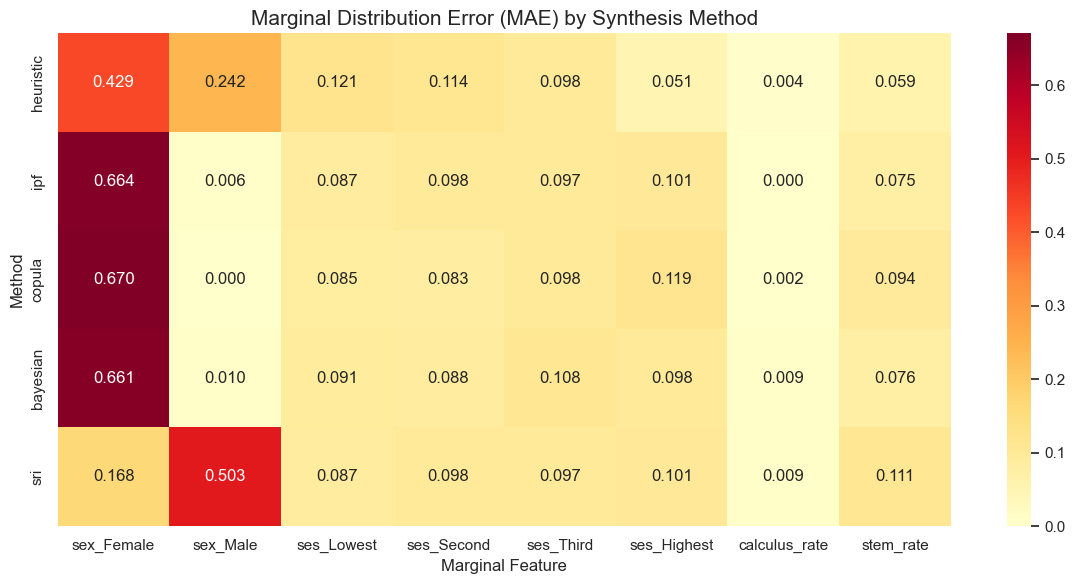

In [3]:
univariate_errors = {m: res['univariate_mae'] for m, res in all_results.items()}
error_df = pd.DataFrame(univariate_errors).T

plt.figure(figsize=(12, 6))
sns.heatmap(error_df, annot=True, cmap='YlOrRd', fmt='.3f')
plt.title("Marginal Distribution Error (MAE) by Synthesis Method", fontsize=15)
plt.ylabel("Method")
plt.xlabel("Marginal Feature")
plt.tight_layout()
plt.show()

## 3. Bivariate Fidelity: Conditional Probabilities
A key test of synthesis is whether it preserves relationships, such as $P(\text{STEM} | \text{Sex})$ or $P(\text{STEM} | \text{Calculus})$.

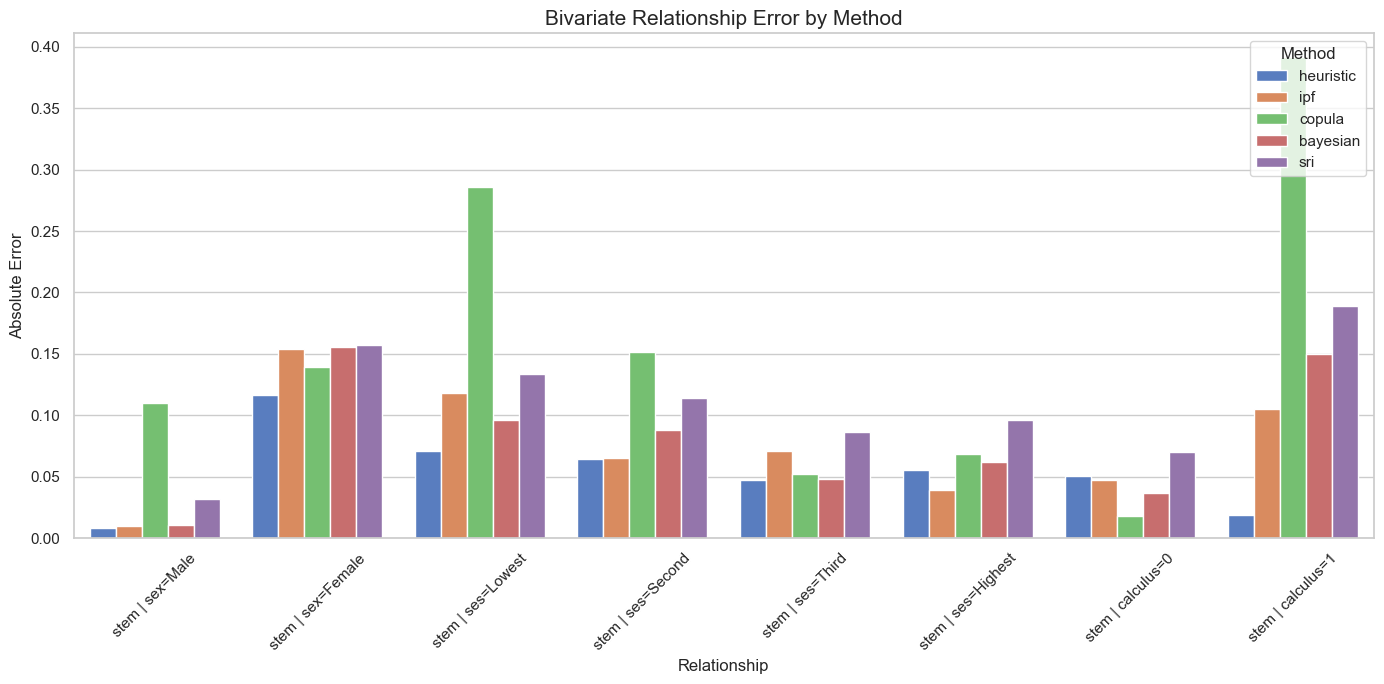

In [4]:
bivariate_data = []
for method, res in all_results.items():
    for (var, cond), vals in res['bivariate'].items():
        bivariate_data.append({
            'Method': method,
            'Relationship': f"{var} | {cond}",
            'Synthetic Prob': vals['synthetic'],
            'NCES Prob': vals['nces'],
            'Error': vals['error']
        })

biv_df = pd.DataFrame(bivariate_data)

plt.figure(figsize=(14, 7))
sns.barplot(data=biv_df, x='Relationship', y='Error', hue='Method')
plt.xticks(rotation=45)
plt.title("Bivariate Relationship Error by Method", fontsize=15)
plt.ylabel("Absolute Error")
plt.legend(title='Method', loc='upper right')
plt.tight_layout()
plt.show()

## 4. Correlation Structure Analysis
The Copula and SRI methods are expected to preserve internal correlations better than simple heuristic sampling.

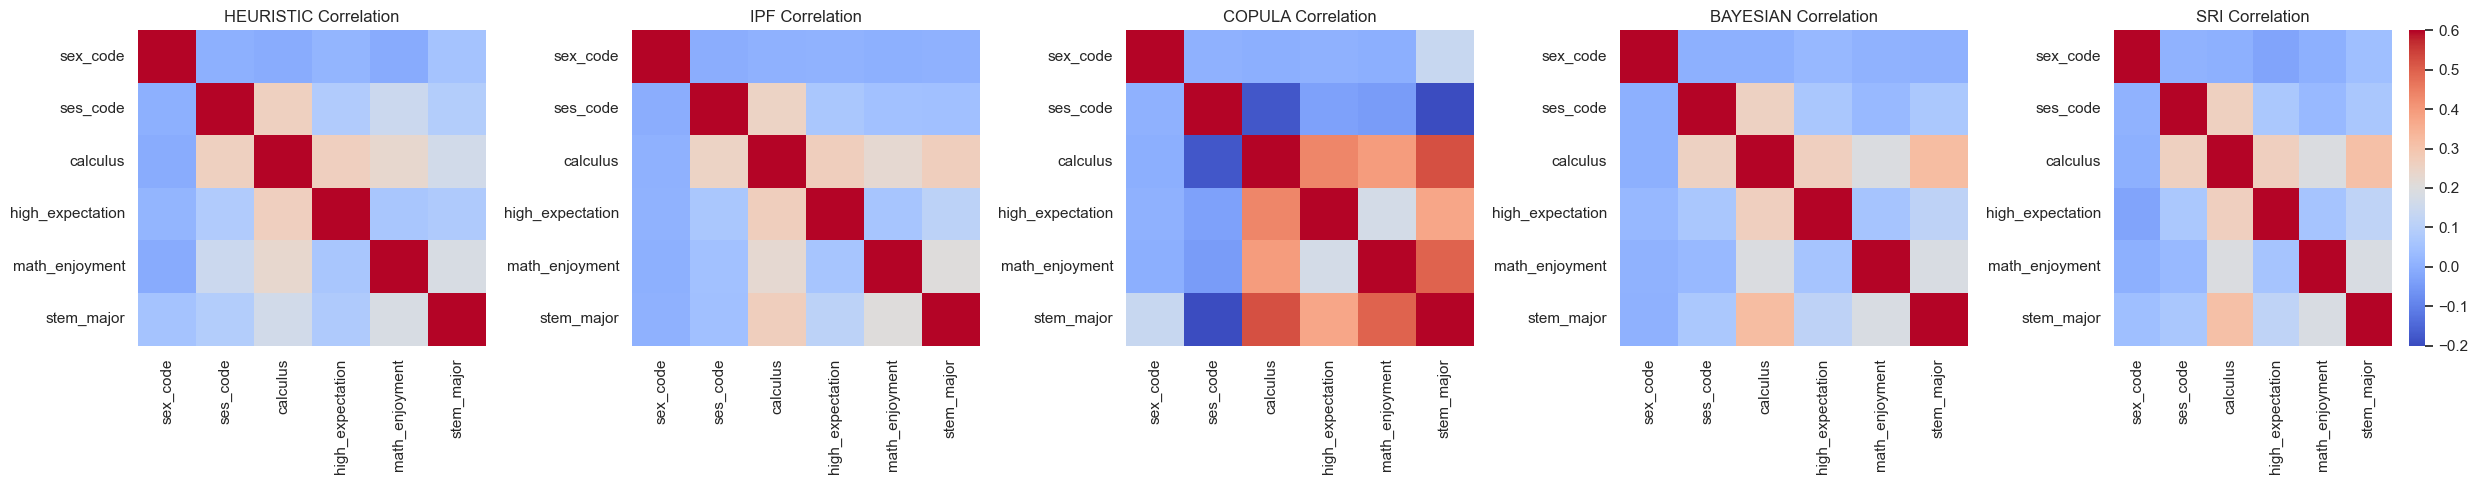

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, method in enumerate(methods):
    if method in all_results:
        corr = all_results[method]['correlation']
        sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-0.2, vmax=0.6, ax=axes[i], cbar=(i==4))
        axes[i].set_title(f"{method.upper()} Correlation")
    else:
        axes[i].set_title(f"{method.upper()} (Missing)")

plt.tight_layout()
plt.show()

## 5. Method Ranking and Recommendation
We rank the methods based on their overall Mean Absolute Error (MAE) across all marginal constraints.

In [6]:
rank_df = pd.DataFrame({
    'Method': list(all_results.keys()),
    'Overall MAE': [res['overall_mae'] for res in all_results.values()],
    'Overall RMSE': [res['overall_rmse'] for res in all_results.values()]
}).sort_values('Overall MAE')

print("\nMethod Fidelity Rankings (Lower is Better):")
print(rank_df.to_string(index=False))

best_method = rank_df.iloc[0]['Method']
print(f"\nRecommendation: The '{best_method}' method provides the highest fidelity to NCES marginals.")


Method Fidelity Rankings (Lower is Better):
   Method  Overall MAE  Overall RMSE
heuristic     0.096820      0.140648
      ipf     0.108765      0.184659
 bayesian     0.111723      0.185551
      sri     0.128224      0.166578
   copula     0.147977      0.222613

Recommendation: The 'heuristic' method provides the highest fidelity to NCES marginals.
